In [1]:
# Installing a library (package)
!pip install librosa

# Importing libraries (tools we need)
import os                              # Operating system functions
from pathlib import Path               # Handle file paths easily
import numpy as np                     # Numerical operations (arrays, math)
import librosa                         # Audio processing library
import librosa.display                 # Visualization for audio
import matplotlib.pyplot as plt        # Plotting/graphs
import tensorflow as tf                # Machine learning framework
from IPython.display import Audio, display  # Play audio in notebook


In [2]:
# URL where the dataset is stored online
DATASET_URL = "http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip"

# Download and extract the dataset
data_path = tf.keras.utils.get_file(
    fname="mini_speech_commands",    # Name to save as
    origin=DATASET_URL,              # Where to download from
    extract=True,                    # Unzip the file
    cache_dir=".",                   # Save in current folder
    cache_subdir="data"              # Inside a 'data' subfolder
)

# Create a Path object pointing to our data
data_dir = Path("./data/mini_speech_commands/mini_speech_commands")
print("data_dir:", data_dir)

182082353/182082353 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
data_dir: data/mini_speech_commands/mini_speech_commands


In [3]:
# List all folders (each folder = one class/command)
commands = [item.name for item in data_dir.iterdir() if item.is_dir()]
print("Classes:", commands)

# Output: Classes: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']

Classes: ['down', 'right', 'left', 'up', 'go', 'stop', 'no', 'yes']


In [5]:
#📊 Visualize Dataset Structure
# Let's add code to visualize the dataset structure
print("\n📂 DATASET STRUCTURE:")
print("=" * 50)

for command in commands:
    files = list(data_dir.glob(f"{command}/*.wav"))
    print(f"  📁 {command}: {len(files)} audio files")

print("=" * 50)
print(f"  Total classes: {len(commands)}")


📂 DATASET STRUCTURE:
  📁 down: 1000 audio files
  📁 right: 1000 audio files
  📁 left: 1000 audio files
  📁 up: 1000 audio files
  📁 go: 1000 audio files
  📁 stop: 1000 audio files
  📁 no: 1000 audio files
  📁 yes: 1000 audio files
  Total classes: 8


In [7]:
#🎵 Part 4: Load One Audio File
# Pick the first class
target = commands[0]  # e.g., 'down'

# Get all .wav files in that folder
files = list(data_dir.glob(f"{target}/*.wav"))

# Pick the first file
sample_file = files[0]
print("sample_file:", sample_file)

# Load the audio file
waveform, sample_rate = librosa.load(sample_file)
print("waveform shape:", waveform.shape)
print("Sample Rate:", sample_rate)

sample_file: data/mini_speech_commands/mini_speech_commands/down/19e246ad_nohash_0.wav
waveform shape: (22050,)
Sample Rate: 22050


In [8]:
# 📊 Visualize: Raw Audio Data
# Add this code to see the raw data

print("\n" + "="*60)
print("📊 PHASE 1: RAW WAVEFORM")
print("="*60)

print(f"\n📈 Waveform Statistics:")
print(f"   Shape: {waveform.shape}")
print(f"   Sample Rate: {sample_rate} Hz")
print(f"   Duration: {len(waveform)/sample_rate:.2f} seconds")
print(f"   Total Samples: {len(waveform)}")
print(f"   Min Amplitude: {waveform.min():.4f}")
print(f"   Max Amplitude: {waveform.max():.4f}")

print(f"\n🔢 First 10 samples (raw numbers):")
print(f"   {waveform[:10]}")

# Listen to the audio
print(f"\n🔊 Playing audio...")
display(Audio(waveform, rate=sample_rate))


📊 PHASE 1: RAW WAVEFORM

📈 Waveform Statistics:
   Shape: (22050,)
   Sample Rate: 22050 Hz
   Duration: 1.00 seconds
   Total Samples: 22050
   Min Amplitude: -0.1154
   Max Amplitude: 0.1264

🔢 First 10 samples (raw numbers):
   [-0.01341441 -0.01935691 -0.01962714 -0.01921843 -0.01909157 -0.02011476
 -0.02289219 -0.02418492 -0.02278195 -0.02031068]

🔊 Playing audio...


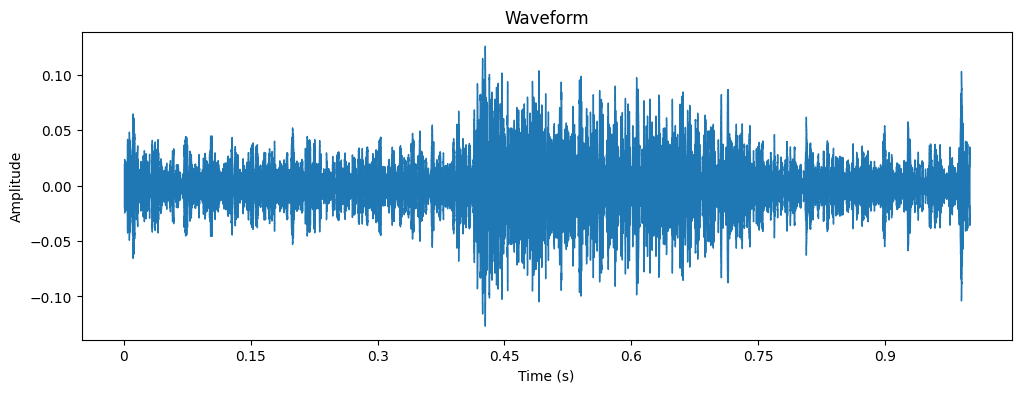

In [10]:
# 📈 Part 5: Visualize Waveform
plt.figure(figsize=(12, 4))
librosa.display.waveshow(waveform, sr=sample_rate)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

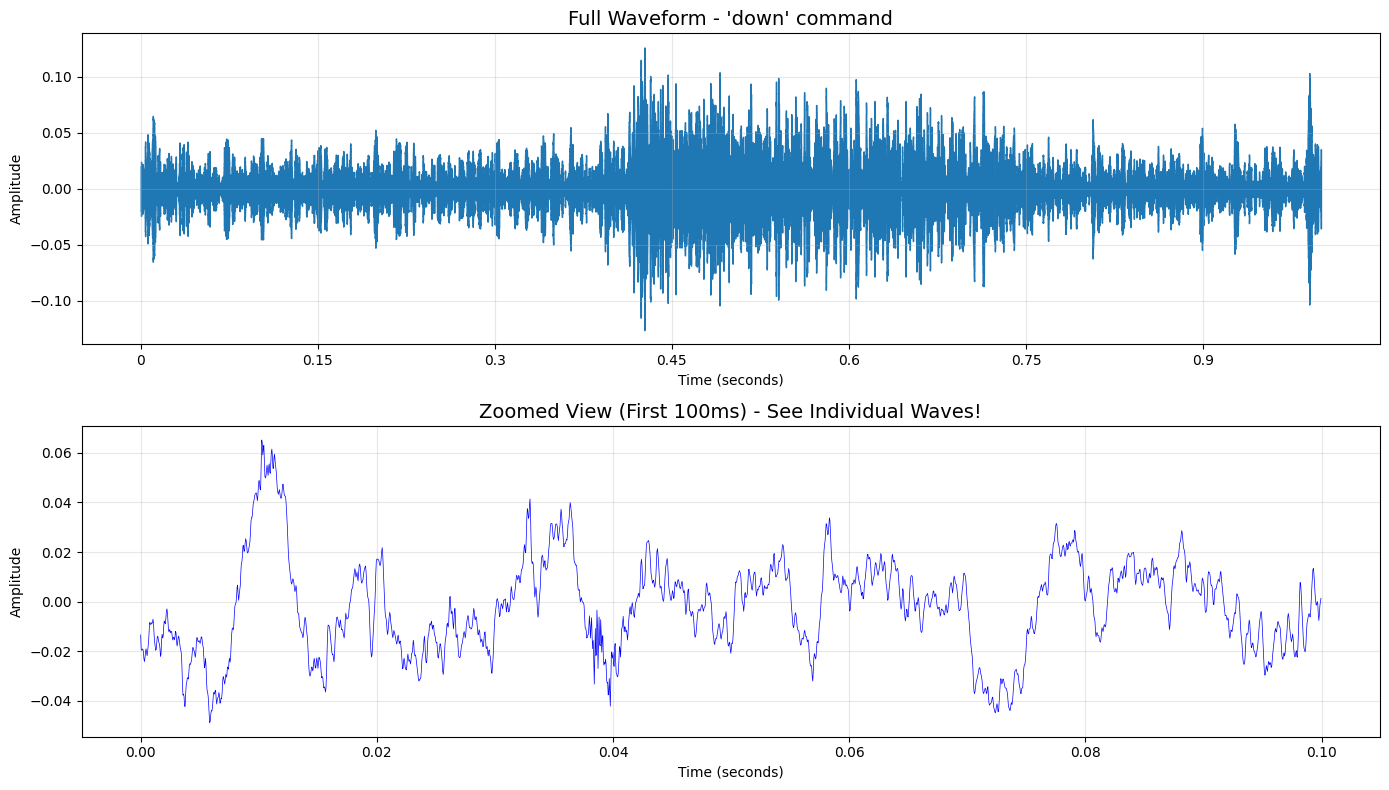

💡 Notice: The zoomed view shows the actual sound waves!
   Each 'wiggle' is a vibration in the air


In [11]:
# 📊 Enhanced Waveform Visualization
# Better visualization with more info

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Full waveform
axes[0].set_title(f"Full Waveform - '{target}' command", fontsize=14)
librosa.display.waveshow(waveform, sr=sample_rate, ax=axes[0])
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# Plot 2: Zoomed in (first 0.1 seconds)
zoom_samples = int(0.1 * sample_rate)  # First 100ms
time_axis = np.arange(zoom_samples) / sample_rate

axes[1].set_title("Zoomed View (First 100ms) - See Individual Waves!", fontsize=14)
axes[1].plot(time_axis, waveform[:zoom_samples], color='blue', linewidth=0.5)
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Notice: The zoomed view shows the actual sound waves!")
print("   Each 'wiggle' is a vibration in the air")

In [13]:
# 🌊 Part 6: STFT & Spectrogram
# Parameters
n_fft = 512       # FFT window size
hop_length = 256  # How much to slide the window

# Compute Short-Time Fourier Transform
stft = librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length)
spectrogram = np.abs(stft)  # Get magnitude (throw away phase)

print("Spectrogram Shape:", spectrogram.shape)

Spectrogram Shape: (257, 87)


In [14]:
#📊 Before & After STFT
print("\n" + "="*60)
print("📊 PHASE 2 & 3: FRAMING + FFT → SPECTROGRAM")
print("="*60)

print(f"\n⚙️ Parameters:")
print(f"   n_fft (window size): {n_fft} samples")
print(f"   hop_length (step): {hop_length} samples")
print(f"   overlap: {n_fft - hop_length} samples ({(n_fft-hop_length)/n_fft*100:.0f}%)")

print(f"\n📥 BEFORE (Time Domain):")
print(f"   Shape: {waveform.shape}")
print(f"   Meaning: {len(waveform)} amplitude values over time")
print(f"   Data: [0.01, -0.02, 0.03, ...] (amplitude at each moment)")

print(f"\n📤 AFTER (Frequency Domain):")
print(f"   Shape: {spectrogram.shape}")
print(f"   Meaning: {spectrogram.shape[0]} frequency bins × {spectrogram.shape[1]} time frames")
print(f"   Frequency bins: 0 Hz to {sample_rate//2} Hz")
print(f"   Time frames: {spectrogram.shape[1]} snapshots")

# Calculate frequency resolution
freq_resolution = sample_rate / n_fft
time_resolution = hop_length / sample_rate * 1000  # in ms

print(f"\n📐 Resolution:")
print(f"   Frequency resolution: {freq_resolution:.1f} Hz per bin")
print(f"   Time resolution: {time_resolution:.1f} ms per frame")


📊 PHASE 2 & 3: FRAMING + FFT → SPECTROGRAM

⚙️ Parameters:
   n_fft (window size): 512 samples
   hop_length (step): 256 samples
   overlap: 256 samples (50%)

📥 BEFORE (Time Domain):
   Shape: (22050,)
   Meaning: 22050 amplitude values over time
   Data: [0.01, -0.02, 0.03, ...] (amplitude at each moment)

📤 AFTER (Frequency Domain):
   Shape: (257, 87)
   Meaning: 257 frequency bins × 87 time frames
   Frequency bins: 0 Hz to 11025 Hz
   Time frames: 87 snapshots

📐 Resolution:
   Frequency resolution: 43.1 Hz per bin
   Time resolution: 11.6 ms per frame


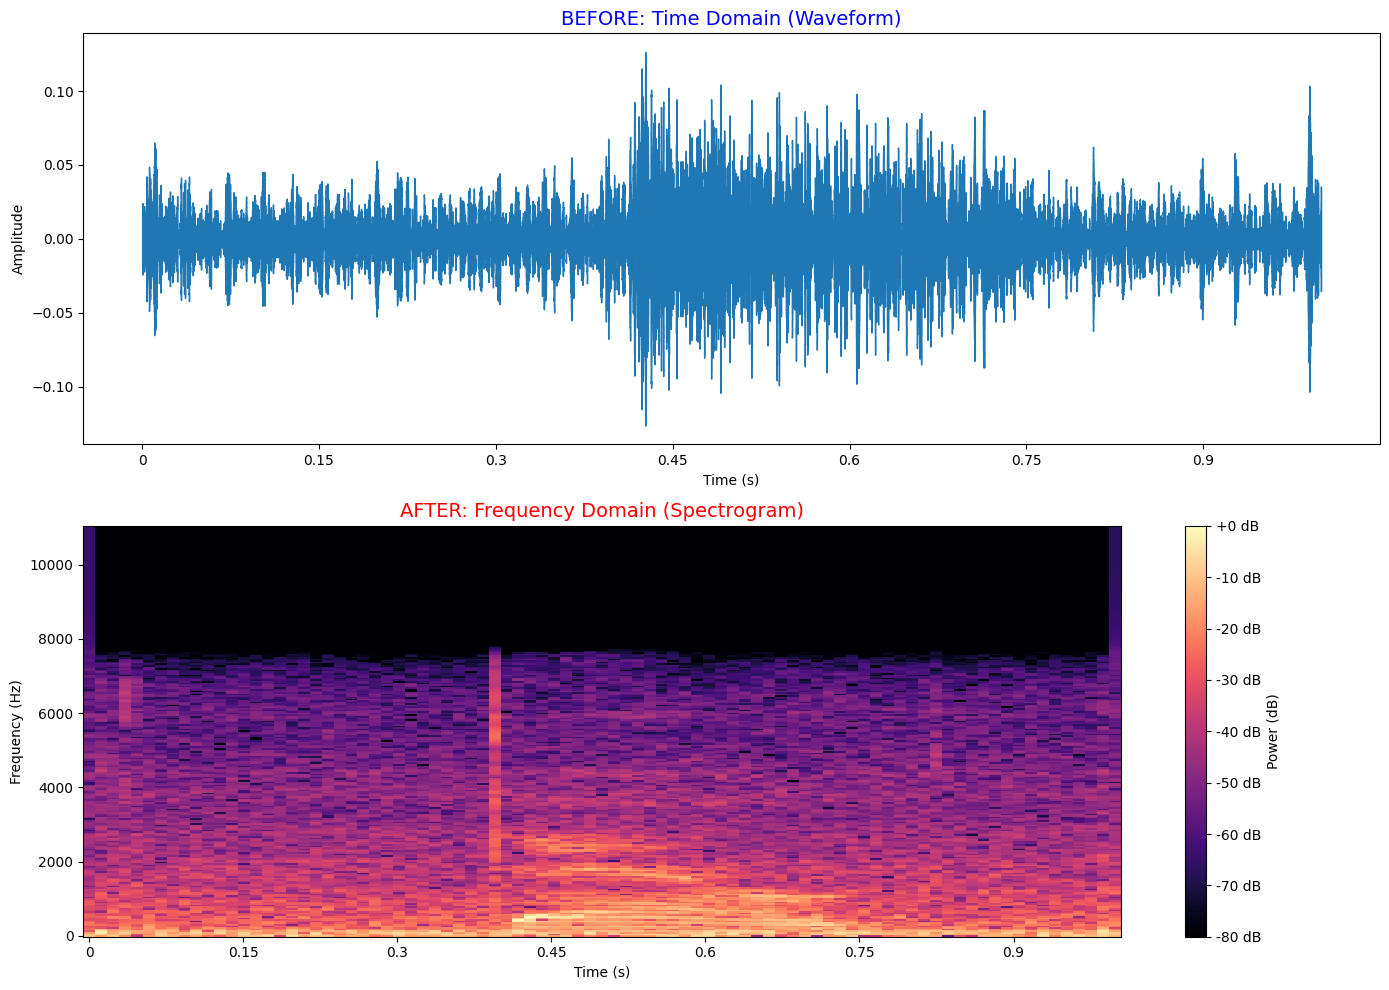


💡 Reading the Spectrogram:
   • X-axis: Time (like the waveform)
   • Y-axis: Frequency (low at bottom, high at top)
   • Color: Energy (brighter = louder at that frequency)


In [16]:
# 📊 Visualize Spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Waveform (BEFORE)
axes[0].set_title("BEFORE: Time Domain (Waveform)", fontsize=14, color='blue')
librosa.display.waveshow(waveform, sr=sample_rate, ax=axes[0])
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Plot 2: Spectrogram (AFTER)
axes[1].set_title("AFTER: Frequency Domain (Spectrogram)", fontsize=14, color='red')
img = librosa.display.specshow(
    librosa.amplitude_to_db(spectrogram, ref=np.max),
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=axes[1]
)
plt.colorbar(img, ax=axes[1], format="%+2.0f dB", label="Power (dB)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

print("\n💡 Reading the Spectrogram:")
print("   • X-axis: Time (like the waveform)")
print("   • Y-axis: Frequency (low at bottom, high at top)")
print("   • Color: Energy (brighter = louder at that frequency)")

In [17]:
# 🎵 Part 7: Mel Spectrogram
# Compute Mel Spectrogram
mel_spectrogram = librosa.feature.melspectrogram(
    y=waveform,
    sr=sample_rate,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=40  # Number of Mel bands
)

# Convert to decibels (log scale)
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

In [18]:
# 📊 Before & After Mel Scale
print("\n" + "="*60)
print("📊 PHASE 4 & 5: MEL SCALE")
print("="*60)

print(f"\n📥 BEFORE (Linear Spectrogram):")
print(f"   Shape: {spectrogram.shape}")
print(f"   Frequency bins: {spectrogram.shape[0]} (linearly spaced)")
print(f"   Equal spacing: Every {freq_resolution:.1f} Hz")

print(f"\n📤 AFTER (Mel Spectrogram):")
print(f"   Shape: {mel_spectrogram.shape}")
print(f"   Mel bands: {mel_spectrogram.shape[0]} (perceptually spaced)")
print(f"   More detail in low frequencies, less in high")

print(f"\n📉 Data Reduction:")
print(f"   {spectrogram.shape[0]} → {mel_spectrogram.shape[0]} frequency bins")
print(f"   Reduction: {(1 - mel_spectrogram.shape[0]/spectrogram.shape[0])*100:.1f}%")


📊 PHASE 4 & 5: MEL SCALE

📥 BEFORE (Linear Spectrogram):
   Shape: (257, 87)
   Frequency bins: 257 (linearly spaced)
   Equal spacing: Every 43.1 Hz

📤 AFTER (Mel Spectrogram):
   Shape: (40, 87)
   Mel bands: 40 (perceptually spaced)
   More detail in low frequencies, less in high

📉 Data Reduction:
   257 → 40 frequency bins
   Reduction: 84.4%


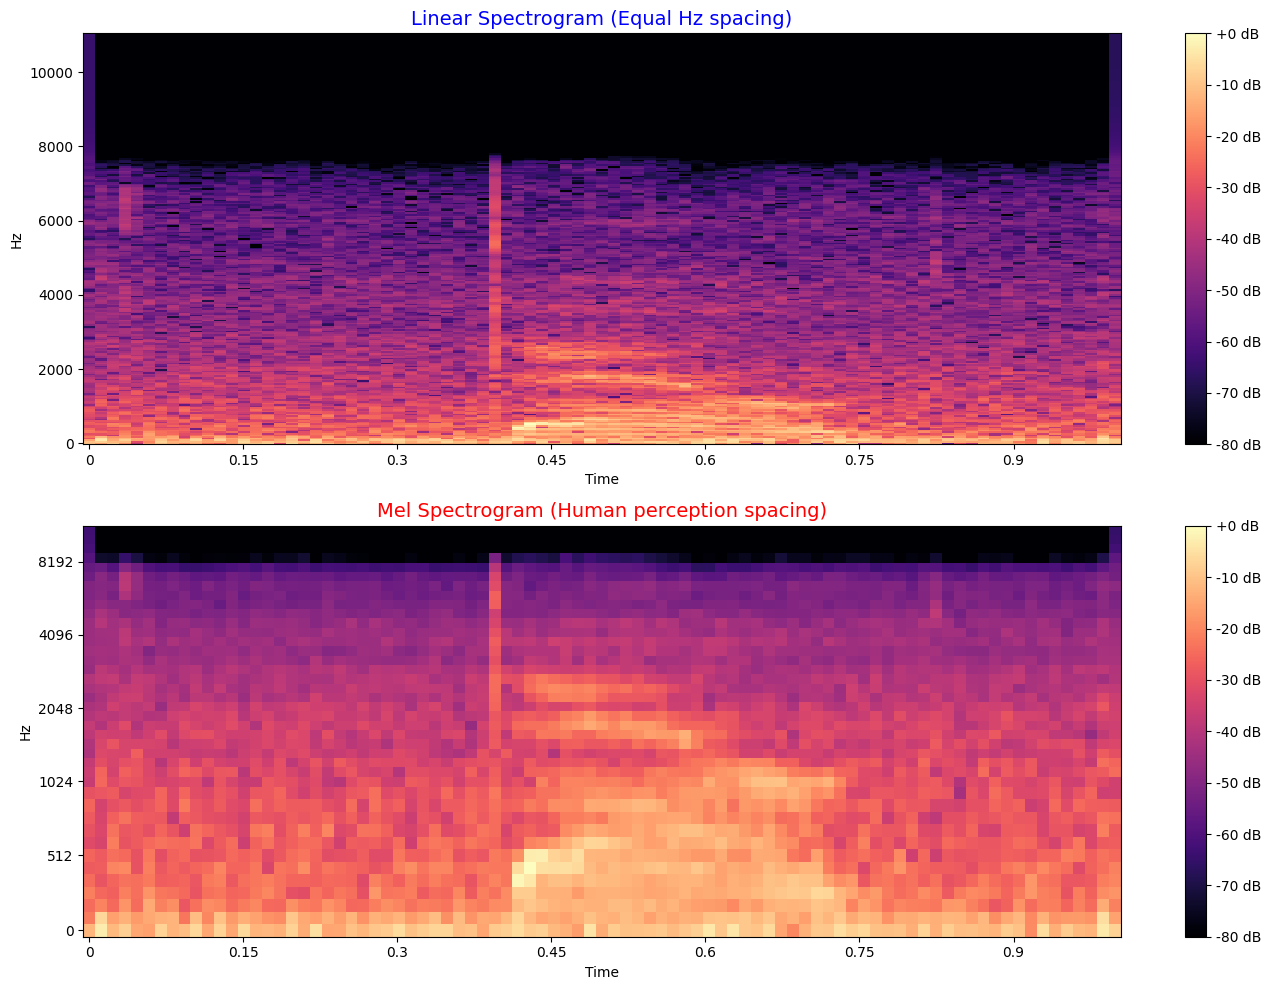


💡 Difference:
   • Linear: Equal spacing (0-1000Hz same size as 1000-2000Hz)
   • Mel: More space for low frequencies (where speech info is)


In [21]:
# 📊 Compare Linear vs Mel Spectrogram
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Linear Spectrogram
axes[0].set_title("Linear Spectrogram (Equal Hz spacing)", fontsize=14, color='blue')
img1 = librosa.display.specshow(
    librosa.amplitude_to_db(spectrogram, ref=np.max),
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz",
    ax=axes[0]
)
plt.colorbar(img1, ax=axes[0], format="%+2.0f dB")

# Plot 2: Mel Spectrogram
axes[1].set_title("Mel Spectrogram (Human perception spacing)", fontsize=14, color='red')
img2 = librosa.display.specshow(
    mel_spectrogram_db,
    sr=sample_rate,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel",
    ax=axes[1]
)
plt.colorbar(img2, ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

print("\n💡 Difference:")
print("   • Linear: Equal spacing (0-1000Hz same size as 1000-2000Hz)")
print("   • Mel: More space for low frequencies (where speech info is)")

In [22]:
# 🎯 Part 8: MFCCs
# Compute MFCCs
mfcc = librosa.feature.mfcc(
    y=waveform,
    sr=sample_rate,
    n_mfcc=13,         # Number of coefficients
    n_fft=n_fft,
    hop_length=hop_length
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (13, 87)


In [23]:
# 📊 Before & After MFCCs
print("\n" + "="*60)
print("📊 PHASE 6: MFCCs (Final Features)")
print("="*60)

print(f"\n📥 BEFORE (Mel Spectrogram):")
print(f"   Shape: {mel_spectrogram.shape}")
print(f"   Values: {mel_spectrogram.shape[0]} mel bands × {mel_spectrogram.shape[1]} frames")
print(f"   Total: {mel_spectrogram.shape[0] * mel_spectrogram.shape[1]} values")

print(f"\n📤 AFTER (MFCCs):")
print(f"   Shape: {mfcc.shape}")
print(f"   Values: {mfcc.shape[0]} coefficients × {mfcc.shape[1]} frames")
print(f"   Total: {mfcc.shape[0] * mfcc.shape[1]} values")

print(f"\n📉 Final Data Reduction (from raw audio):")
print(f"   Raw audio: {len(waveform)} samples")
print(f"   MFCCs: {mfcc.shape[0] * mfcc.shape[1]} values")
print(f"   Reduction: {(1 - (mfcc.shape[0] * mfcc.shape[1])/len(waveform))*100:.1f}%")

print(f"\n🔢 Sample MFCC values (first frame):")
print(f"   {mfcc[:, 0]}")


📊 PHASE 6: MFCCs (Final Features)

📥 BEFORE (Mel Spectrogram):
   Shape: (40, 87)
   Values: 40 mel bands × 87 frames
   Total: 3480 values

📤 AFTER (MFCCs):
   Shape: (13, 87)
   Values: 13 coefficients × 87 frames
   Total: 1131 values

📉 Final Data Reduction (from raw audio):
   Raw audio: 22050 samples
   MFCCs: 1131 values
   Reduction: 94.9%

🔢 Sample MFCC values (first frame):
   [-474.07773    130.1754       3.9056425   33.377396    -8.5032
   10.101367     1.0632496   10.54003     11.055319     8.751293
   -0.5993432   -4.4806056    1.5970459]


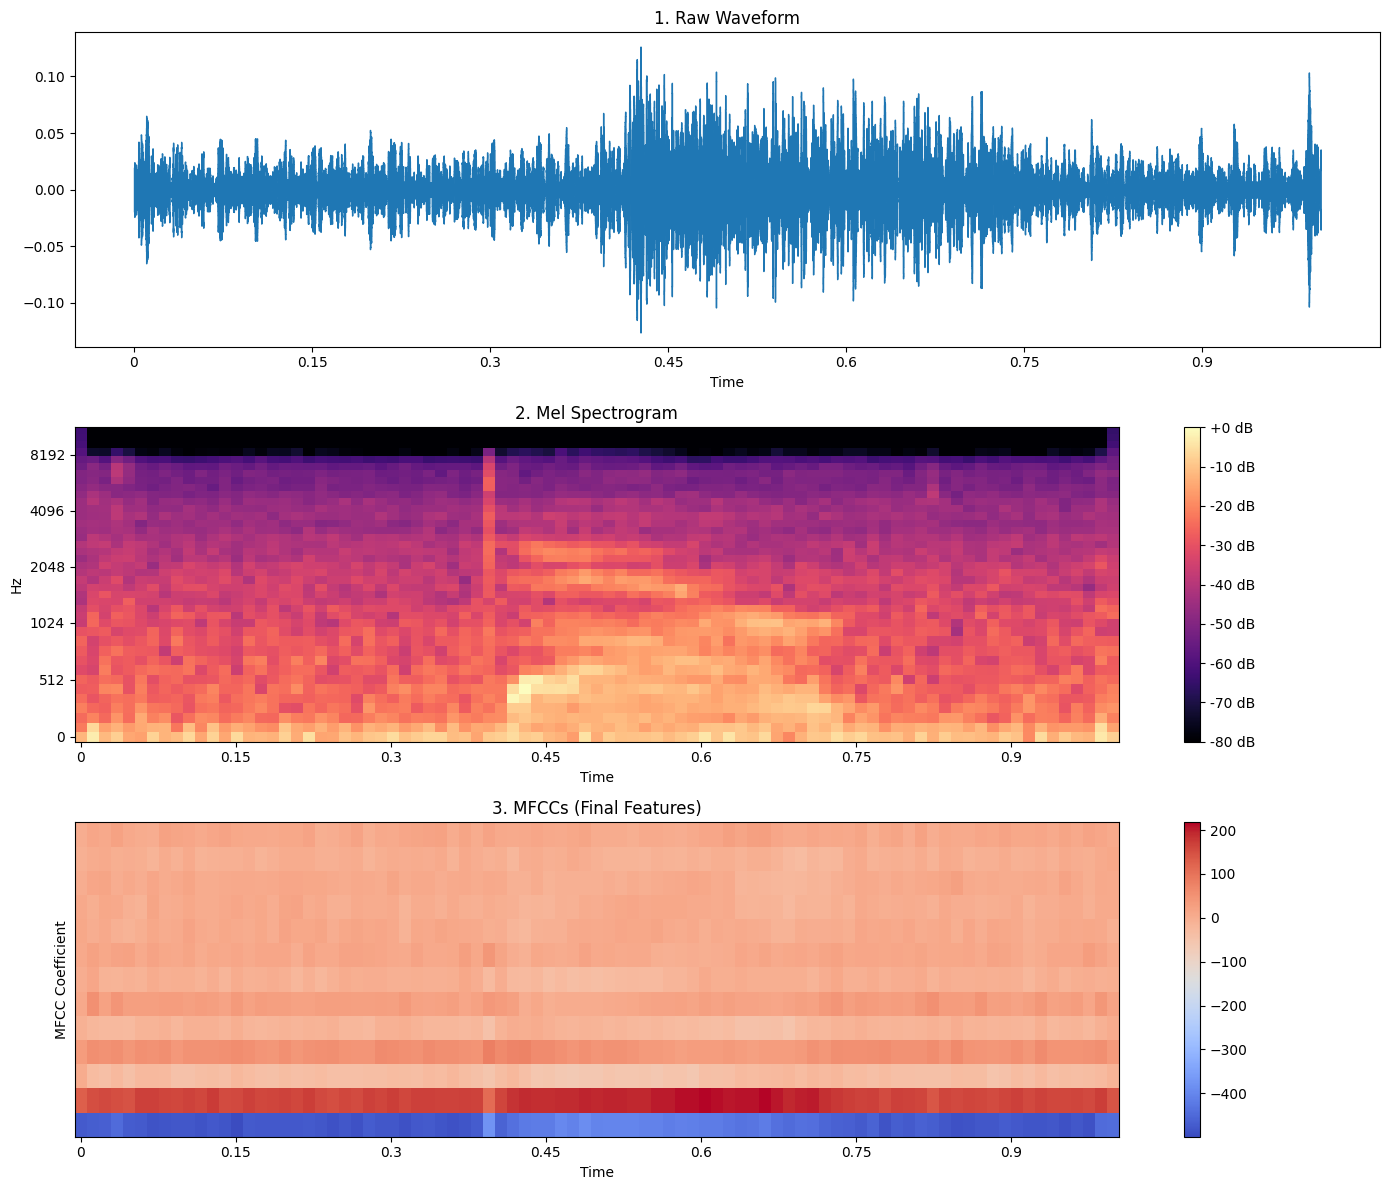

In [24]:
#📊 Visualize MFCCs
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Waveform
axes[0].set_title("1. Raw Waveform", fontsize=12)
librosa.display.waveshow(waveform, sr=sample_rate, ax=axes[0])

# Plot 2: Mel Spectrogram
axes[1].set_title("2. Mel Spectrogram", fontsize=12)
img1 = librosa.display.specshow(mel_spectrogram_db, sr=sample_rate,
                                 hop_length=hop_length, x_axis="time",
                                 y_axis="mel", ax=axes[1])
plt.colorbar(img1, ax=axes[1], format="%+2.0f dB")

# Plot 3: MFCCs
axes[2].set_title("3. MFCCs (Final Features)", fontsize=12)
img2 = librosa.display.specshow(mfcc, sr=sample_rate,
                                 hop_length=hop_length, x_axis="time",
                                 ax=axes[2])
plt.colorbar(img2, ax=axes[2])
axes[2].set_ylabel("MFCC Coefficient")

plt.tight_layout()
plt.show()

In [25]:
# 🔄 Part 9: Complete Pipeline Summary
print("\n" + "="*70)
print("📊 COMPLETE PIPELINE SUMMARY")
print("="*70)

print("""
┌─────────────────────────────────────────────────────────────────────────┐
│  STAGE          │  SHAPE          │  DATA TYPE        │  REDUCTION     │
├─────────────────────────────────────────────────────────────────────────┤
│  Raw Audio      │  ({:>6},)       │  Amplitude values │  -             │
│  Spectrogram    │  ({:>3}, {:>3})     │  Power at freq    │  {:>5.1f}%        │
│  Mel Spec       │  ({:>3}, {:>3})     │  Mel-scaled power │  {:>5.1f}%        │
│  MFCCs          │  ({:>3}, {:>3})     │  Cepstral coef    │  {:>5.1f}%        │
└─────────────────────────────────────────────────────────────────────────┘
""".format(
    len(waveform),
    spectrogram.shape[0], spectrogram.shape[1],
    (1 - spectrogram.size/len(waveform))*100,
    mel_spectrogram.shape[0], mel_spectrogram.shape[1],
    (1 - mel_spectrogram.size/len(waveform))*100,
    mfcc.shape[0], mfcc.shape[1],
    (1 - mfcc.size/len(waveform))*100
))



📊 COMPLETE PIPELINE SUMMARY

┌─────────────────────────────────────────────────────────────────────────┐
│  STAGE          │  SHAPE          │  DATA TYPE        │  REDUCTION     │
├─────────────────────────────────────────────────────────────────────────┤
│  Raw Audio      │  ( 22050,)       │  Amplitude values │  -             │
│  Spectrogram    │  (257,  87)     │  Power at freq    │   -1.4%        │
│  Mel Spec       │  ( 40,  87)     │  Mel-scaled power │   84.2%        │
│  MFCCs          │  ( 13,  87)     │  Cepstral coef    │   94.9%        │
└─────────────────────────────────────────────────────────────────────────┘

